In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [2]:
stock_df   = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\POWERGRID_Historical_Data.csv")
call_df    = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\Call_option_Data.csv")
put_df  = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\Put_Option_Data.csv")
lot_df    = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\Lot_Size_List.csv")

# Strip whitespace from column names (data has trailing spaces)
for df in [call_df, put_df, stock_df, lot_df]:
    df.columns = df.columns.str.strip()

print("Call Options:", call_df.shape)
print("Put Options:", put_df.shape)
print("Stock Data:", stock_df.shape)
print("Lot Size:", lot_df.shape)

Call Options: (497, 10)
Put Options: (497, 10)
Stock Data: (497, 5)
Lot Size: (24, 2)


Month_Label  Entry   Exit   Return_%
    2023-10 199.55 202.15   1.302932
    2023-11 200.95 208.95   3.981090
    2023-12 210.20 237.20  12.844910
    2024-01 238.25 259.30   8.835257
    2024-02 265.80 282.85   6.414597
    2024-03 287.70 276.90  -3.753910
    2024-04 280.15 301.85   7.745850
    2024-05 313.60 310.00  -1.147959
    2024-06 337.65 330.95  -1.984303
    2024-07 329.60 348.20   5.643204
    2024-08 361.10 337.40  -6.563279
    2024-09 335.55 352.85   5.155714
    2024-10 350.80 320.80  -8.551881
    2024-11 322.05 329.40   2.282254
    2024-12 327.85 308.70  -5.841086
    2025-01 310.40 301.65  -2.818943
    2025-02 289.85 250.85 -13.455235
    2025-03 252.50 290.35  14.990099
    2025-04 289.30 307.45   6.273764
    2025-05 303.95 289.75  -4.671821
    2025-06 293.05 299.90   2.337485
    2025-07 297.55 291.00  -2.201311
    2025-08 291.25 275.25  -5.493562
    2025-09 279.85 280.25   0.142934


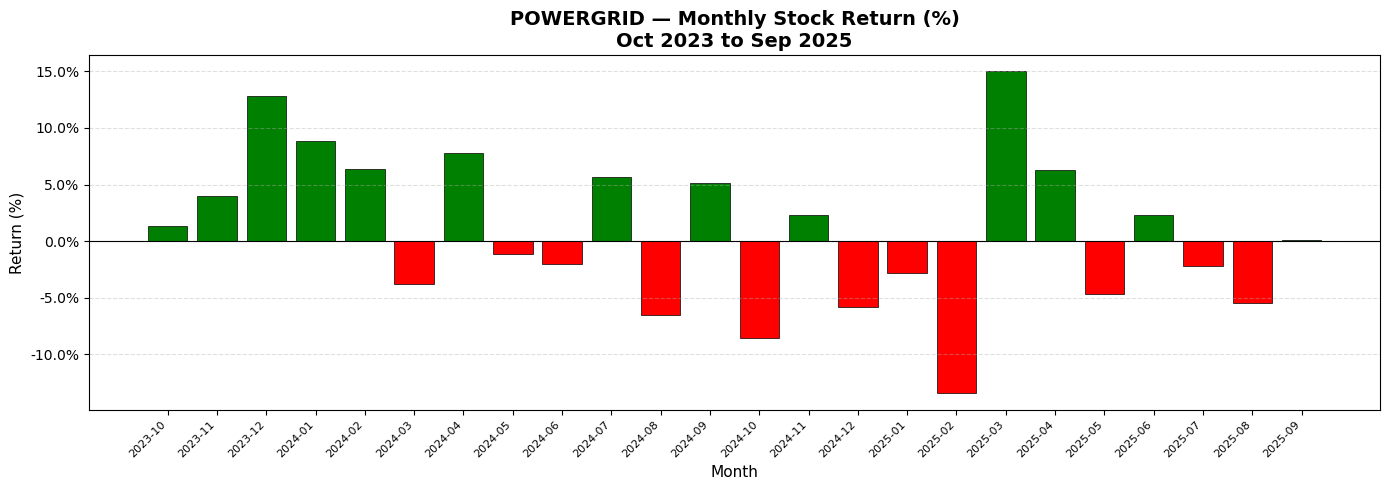

In [3]:
# Parse dates
stock_df['DATE'] = pd.to_datetime(stock_df['DATE'], dayfirst=True)

# Sort just in case
stock_df = stock_df.sort_values('DATE').reset_index(drop=True)

# Create Year-Month column
stock_df['YearMonth'] = stock_df['DATE'].dt.to_period('M')

# For each month: first close = entry price, last close = exit price
monthly = stock_df.groupby('YearMonth')['CLOSE'].agg(
    Entry='first',
    Exit='last'
).reset_index()

monthly['Return_%'] = ((monthly['Exit'] - monthly['Entry']) / monthly['Entry']) * 100
monthly['Month_Label'] = monthly['YearMonth'].astype(str)

print(monthly[['Month_Label', 'Entry', 'Exit', 'Return_%']].to_string(index=False))

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['green' if r >= 0 else 'red' for r in monthly['Return_%']]
bars = ax.bar(monthly['Month_Label'], monthly['Return_%'], color=colors, edgecolor='black', linewidth=0.5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('POWERGRID — Monthly Stock Return (%)\nOct 2023 to Sep 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Return (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [4]:
# ── Stock Performance Metrics ──────────────────────────────────────────

start_price = stock_df.loc[stock_df['DATE'] == stock_df['DATE'].min(), 'CLOSE'].values[0]
end_price   = stock_df.loc[stock_df['DATE'] == stock_df['DATE'].max(), 'CLOSE'].values[0]

start_date  = stock_df['DATE'].min()
end_date    = stock_df['DATE'].max()
n_days      = (end_date - start_date).days
n_years     = n_days / 365.25

# ── Core Return Metrics ───────────────────────────────────────────────
absolute_return  = ((end_price - start_price) / start_price) * 100
cagr             = ((end_price / start_price) ** (1 / n_years) - 1) * 100

# ── Daily Returns ─────────────────────────────────────────────────────
stock_df['Daily_Return'] = stock_df['CLOSE'].pct_change()
daily_returns = stock_df['Daily_Return'].dropna()

# ── Risk Metrics ──────────────────────────────────────────────────────
avg_daily_return     = daily_returns.mean()
daily_volatility     = daily_returns.std()
annual_volatility    = daily_volatility * np.sqrt(252) * 100

risk_free_rate       = 0.065   # ~6.5% India 10yr G-sec
sharpe_ratio         = (cagr/100 - risk_free_rate) / (annual_volatility/100)

downside_returns     = daily_returns[daily_returns < 0]
downside_std         = downside_returns.std() * np.sqrt(252)
sortino_ratio        = (cagr/100 - risk_free_rate) / downside_std

# ── Drawdown ──────────────────────────────────────────────────────────
stock_df['Cumulative'] = (1 + stock_df['Daily_Return'].fillna(0)).cumprod()
stock_df['RollingMax'] = stock_df['Cumulative'].cummax()
stock_df['Drawdown']   = (stock_df['Cumulative'] - stock_df['RollingMax']) / stock_df['RollingMax'] * 100
max_drawdown           = stock_df['Drawdown'].min()

calmar_ratio           = (cagr / 100) / abs(max_drawdown / 100)

# ── Monthly Win Rate ──────────────────────────────────────────────────
win_months    = (monthly['Return_%'] > 0).sum()
total_months  = len(monthly)
win_rate      = (win_months / total_months) * 100

avg_win_return  = monthly.loc[monthly['Return_%'] > 0, 'Return_%'].mean()
avg_loss_return = monthly.loc[monthly['Return_%'] < 0, 'Return_%'].mean()
payoff_ratio    = abs(avg_win_return / avg_loss_return)

best_month  = monthly.loc[monthly['Return_%'].idxmax(), ['Month_Label','Return_%']]
worst_month = monthly.loc[monthly['Return_%'].idxmin(), ['Month_Label','Return_%']]

# ── Print Summary ─────────────────────────────────────────────────────
print("=" * 48)
print("   POWERGRID — BUY & HOLD PERFORMANCE SCORECARD")
print("=" * 48)
print(f"  Period             : {start_date.date()}  →  {end_date.date()}")
print(f"  Start Price        : ₹{start_price:.2f}")
print(f"  End Price          : ₹{end_price:.2f}")
print("-" * 48)
print(f"  Absolute Return    : {absolute_return:.2f}%")
print(f"  CAGR               : {cagr:.2f}%")
print(f"  Annual Volatility  : {annual_volatility:.2f}%")
print("-" * 48)
print(f"  Sharpe Ratio       : {sharpe_ratio:.2f}")
print(f"  Sortino Ratio      : {sortino_ratio:.2f}")
print(f"  Calmar Ratio       : {calmar_ratio:.2f}")
print(f"  Max Drawdown       : {max_drawdown:.2f}%")
print("-" * 48)
print(f"  Monthly Win Rate   : {win_rate:.1f}%  ({win_months}/{total_months} months)")
print(f"  Avg Winning Month  : +{avg_win_return:.2f}%")
print(f"  Avg Losing Month   : {avg_loss_return:.2f}%")
print(f"  Payoff Ratio       : {payoff_ratio:.2f}x")
print(f"  Best Month         : {best_month['Month_Label']}  (+{best_month['Return_%']:.2f}%)")
print(f"  Worst Month        : {worst_month['Month_Label']}  ({worst_month['Return_%']:.2f}%)")
print("=" * 48)

   POWERGRID — BUY & HOLD PERFORMANCE SCORECARD
  Period             : 2023-10-03  →  2025-09-30
  Start Price        : ₹199.55
  End Price          : ₹280.25
------------------------------------------------
  Absolute Return    : 40.44%
  CAGR               : 18.58%
  Annual Volatility  : 27.12%
------------------------------------------------
  Sharpe Ratio       : 0.45
  Sortino Ratio      : 0.61
  Calmar Ratio       : 0.59
  Max Drawdown       : -31.36%
------------------------------------------------
  Monthly Win Rate   : 54.2%  (13/24 months)
  Avg Winning Month  : +6.00%
  Avg Losing Month   : -5.13%
  Payoff Ratio       : 1.17x
  Best Month         : 2025-03  (+14.99%)
  Worst Month        : 2025-02  (-13.46%)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────────────────────────────
stock_df   = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\POWERGRID_Historical_Data.csv")
call_df    = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\Call_option_Data.csv")
put_df  = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\Put_Option_Data.csv")
lot_df    = pd.read_csv(r"C:\Users\pratham Jaiswal\Downloads\Short Straddle\Lot_Size_List.csv")

In [6]:
# ── Strip whitespace from column names ───────────────────────────────
for df in [call_df, put_df, lot_df, stock_df]:
    df.columns = df.columns.str.strip()
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.strip()

# ── Parse dates ───────────────────────────────────────────────────────
call_df['Date']   = pd.to_datetime(call_df['Date'],   dayfirst=True)
call_df['Expiry'] = pd.to_datetime(call_df['Expiry'], dayfirst=True)
put_df['Date']    = pd.to_datetime(put_df['Date'],    dayfirst=True)
put_df['Expiry']  = pd.to_datetime(put_df['Expiry'],  dayfirst=True)
stock_df['DATE']  = pd.to_datetime(stock_df['DATE'],  dayfirst=True)

# ── Parse numeric columns ─────────────────────────────────────────────
for col in ['Open','High','Low','Close','LTP','Strike Price']:
    call_df[col] = pd.to_numeric(call_df[col], errors='coerce')
    put_df[col]  = pd.to_numeric(put_df[col],  errors='coerce')

for col in ['OPEN','HIGH','LOW','CLOSE']:
    stock_df[col] = pd.to_numeric(stock_df[col], errors='coerce')

# ── Parse lot size (remove commas like "3,600") ───────────────────────
lot_df['Lot Size'] = lot_df['Lot Size'].astype(str).str.replace(',','').astype(int)
lot_df['Period']   = pd.to_datetime(lot_df['Month'], format='%b-%y').dt.to_period('M')

print("✅ Data cleaned successfully.")
print(f"   Call rows : {len(call_df)}")
print(f"   Put rows  : {len(put_df)}")
print(f"   Stock rows: {len(stock_df)}")
print(f"   Lot rows  : {len(lot_df)}")

✅ Data cleaned successfully.
   Call rows : 497
   Put rows  : 497
   Stock rows: 497
   Lot rows  : 24


In [7]:
# ── Build monthly trade schedule from PUT data ────────────────────────
trade_schedule = (
    put_df.groupby('Expiry')
    .agg(
        Entry_Date = ('Date',         'min'),
        Strike     = ('Strike Price', 'first')
    )
    .reset_index()
    .sort_values('Entry_Date')
    .reset_index(drop=True)
)

# ── Attach lot size per expiry month ──────────────────────────────────
trade_schedule['Period'] = trade_schedule['Expiry'].dt.to_period('M')
trade_schedule = trade_schedule.merge(lot_df[['Period','Lot Size']], on='Period', how='left')

# ── Filter backtest window ────────────────────────────────────────────
trade_schedule = trade_schedule[
    (trade_schedule['Entry_Date'] >= '2023-10-03') &
    (trade_schedule['Expiry']     <= '2025-09-30')
].reset_index(drop=True)

print("=" * 62)
print("   MONTHLY TRADE SCHEDULE")
print("=" * 62)
print(f"  {'#':<4} {'Entry Date':<14} {'Expiry':<14} {'Strike':>8} {'Lot Size':>9}")
print("-" * 62)
for i, row in trade_schedule.iterrows():
    print(f"  {i+1:<4} {str(row['Entry_Date'].date()):<14} "
          f"{str(row['Expiry'].date()):<14} "
          f"{row['Strike']:>8.0f} {row['Lot Size']:>9}")
print("=" * 62)
print(f"  Total months to backtest : {len(trade_schedule)}")

   MONTHLY TRADE SCHEDULE
  #    Entry Date     Expiry           Strike  Lot Size
--------------------------------------------------------------
  1    2023-10-03     2023-10-26          200      3600
  2    2023-10-27     2023-11-30          200      3600
  3    2023-12-01     2023-12-28          210      3600
  4    2023-12-29     2024-01-25          240      3600
  5    2024-01-29     2024-02-29          255      3600
  6    2024-03-01     2024-03-28          290      3600
  7    2024-04-01     2024-04-25          280      3600
  8    2024-04-26     2024-05-30          295      3600
  9    2024-05-31     2024-06-27          310      3600
  10   2024-06-28     2024-07-25          330      3600
  11   2024-07-26     2024-08-29          345      3600
  12   2024-08-30     2024-09-26          340      3600
  13   2024-09-27     2024-10-31          355      3600
  14   2024-11-01     2024-11-28          335      3600
  15   2024-11-29     2024-12-26          330      3600
  16   2024-12-

In [8]:
results      = []
FIXED_CAPITAL = 130000      # Fixed capital every month
STOPLOSS_AMT  = -20000      # SL at -₹20,000 MTM loss
PROFIT_PCT    = 0.50        # Square off if MTM profit >= 50% of total premium

for i, trade in trade_schedule.iterrows():

    entry_date  = trade['Entry_Date']
    expiry_date = trade['Expiry']
    strike      = trade['Strike']
    lot_size    = trade['Lot Size']

    # ── Entry premiums (Close price on entry day) ─────────────────────
    ce_entry_row = call_df[(call_df['Date'] == entry_date) & (call_df['Expiry'] == expiry_date)]
    pe_entry_row = put_df[ (put_df['Date']  == entry_date) & (put_df['Expiry']  == expiry_date)]

    if ce_entry_row.empty or pe_entry_row.empty:
        print(f"⚠️  Month {i+1}: Missing entry data on {entry_date.date()} — skipping")
        continue

    ce_entry_prem  = ce_entry_row['Close'].values[0]
    pe_entry_prem  = pe_entry_row['Close'].values[0]
    total_prem_unit = ce_entry_prem + pe_entry_prem          # per unit

    # ── Targets ───────────────────────────────────────────────────────
    premium_collected = total_prem_unit * lot_size           # total ₹ received
    profit_target_pnl = PROFIT_PCT * premium_collected       # 50% of premium
    stoploss_pnl      = STOPLOSS_AMT                         # -₹20,000

    # ── Get daily data for this expiry series ─────────────────────────
    ce_series = call_df[(call_df['Expiry'] == expiry_date) &
                        (call_df['Date']   >= entry_date)].sort_values('Date')
    pe_series = put_df[ (put_df['Expiry']  == expiry_date) &
                        (put_df['Date']    >= entry_date)].sort_values('Date')

    all_dates = sorted(set(ce_series['Date'].tolist()) &
                       set(pe_series['Date'].tolist()))

    exit_date    = None
    exit_reason  = None
    pnl          = None
    ce_exit_prem = None
    pe_exit_prem = None

    # ── Daily monitoring ──────────────────────────────────────────────
    for day in all_dates:

        ce_row = ce_series[ce_series['Date'] == day]
        pe_row = pe_series[pe_series['Date'] == day]

        if ce_row.empty or pe_row.empty:
            continue

        # Expiry day → LTP | All other days → Close
        if day == expiry_date:
            ce_today = ce_row['LTP'].values[0]
            pe_today = pe_row['LTP'].values[0]
        else:
            ce_today = ce_row['Close'].values[0]
            pe_today = pe_row['Close'].values[0]

        current_prem = ce_today + pe_today
        daily_pnl    = (total_prem_unit - current_prem) * lot_size

        # ── Check Profit Target ───────────────────────────────────────
        if daily_pnl >= profit_target_pnl:
            exit_date    = day
            exit_reason  = 'Profit Target (50%)'
            pnl          = daily_pnl
            ce_exit_prem = ce_today
            pe_exit_prem = pe_today
            break

        # ── Check Stop Loss ───────────────────────────────────────────
        if daily_pnl <= stoploss_pnl:
            exit_date    = day
            exit_reason  = 'Stop Loss (-₹20,000)'
            pnl          = daily_pnl
            ce_exit_prem = ce_today
            pe_exit_prem = pe_today
            break

        # ── Expiry exit (neither triggered) ───────────────────────────
        if day == expiry_date:
            exit_date    = day
            exit_reason  = 'Expiry'
            pnl          = daily_pnl
            ce_exit_prem = ce_today
            pe_exit_prem = pe_today
            break

    if exit_date is None:
        print(f"⚠️  Month {i+1}: No exit found for {entry_date.date()} — skipping")
        continue

    results.append({
        'Month'              : expiry_date.strftime('%b-%y'),
        'Entry_Date'         : entry_date,
        'Expiry_Date'        : expiry_date,
        'Strike'             : strike,
        'Lot_Size'           : lot_size,
        'CE_Entry'           : ce_entry_prem,
        'PE_Entry'           : pe_entry_prem,
        'Total_Prem_Unit'    : round(total_prem_unit, 2),
        'Premium_Collected'  : round(premium_collected, 2),
        'Profit_Target_₹'   : round(profit_target_pnl, 2),
        'CE_Exit'            : ce_exit_prem,
        'PE_Exit'            : pe_exit_prem,
        'Capital'            : FIXED_CAPITAL,
        'PnL'                : round(pnl, 2),
        'Return_%'           : round((pnl / FIXED_CAPITAL) * 100, 2),
        'Exit_Reason'        : exit_reason,
        'Exit_Date'          : exit_date,
    })

results_df = pd.DataFrame(results)

print("✅ Backtest Complete!")
print(f"   Fixed Capital        : ₹{FIXED_CAPITAL:,}")
print(f"   Stop Loss            : ₹{abs(STOPLOSS_AMT):,}")
print(f"   Profit Target        : 50% of premium collected")
print(f"   Total months traded  : {len(results_df)}")
print(f"   Profit Target exits  : {(results_df['Exit_Reason'] == 'Profit Target (50%)').sum()}")
print(f"   Stop Loss exits      : {(results_df['Exit_Reason'] == 'Stop Loss (-₹20,000)').sum()}")
print(f"   Expiry exits         : {(results_df['Exit_Reason'] == 'Expiry').sum()}")

✅ Backtest Complete!
   Fixed Capital        : ₹130,000
   Stop Loss            : ₹20,000
   Profit Target        : 50% of premium collected
   Total months traded  : 24
   Profit Target exits  : 11
   Stop Loss exits      : 8
   Expiry exits         : 5


In [9]:
print("=" * 88)
print(f"  {'Month':<8} {'Entry':<12} {'Expiry':<12} {'Strike':>7} {'Lot':>5} "
      f"{'CE_En':>6} {'PE_En':>6} {'Premium':>9} {'PT(50%)':>9} "
      f"{'PnL':>9} {'Ret%':>7}  Exit")
print("=" * 88)

for _, r in results_df.iterrows():
    reason = ('PT' if 'Profit' in r['Exit_Reason']
              else 'SL' if 'Stop' in r['Exit_Reason']
              else 'EXP')
    print(f"  {r['Month']:<8} {str(r['Entry_Date'].date()):<12} "
          f"{str(r['Expiry_Date'].date()):<12} {r['Strike']:>7.0f} "
          f"{r['Lot_Size']:>5} {r['CE_Entry']:>6.2f} {r['PE_Entry']:>6.2f} "
          f"{r['Premium_Collected']:>9,.0f} {r['Profit_Target_₹']:>9,.0f} "
          f"{r['PnL']:>9,.0f} {r['Return_%']:>6.2f}%  {reason}")

print("-" * 88)
print(f"  {'TOTAL':<8} {' ':<12} {' ':<12} {' ':>7} {' ':>5} {' ':>6} "
      f"{' ':>6} {' ':>9} {' ':>9} "
      f"{results_df['PnL'].sum():>9,.0f} "
      f"{results_df['Return_%'].sum():>6.2f}%")
print("=" * 88)

  Month    Entry        Expiry        Strike   Lot  CE_En  PE_En   Premium   PT(50%)       PnL    Ret%  Exit
  Oct-23   2023-10-03   2023-10-26       200  3600   5.35   5.00    37,260    18,630    21,420  16.48%  PT
  Nov-23   2023-10-27   2023-11-30       200  3600   4.55   4.55    32,760    16,380    -5,940  -4.57%  EXP
  Dec-23   2023-12-01   2023-12-28       210  3600   7.00   5.00    43,200    21,600   -37,980 -29.22%  SL
  Jan-24   2023-12-29   2024-01-25       240  3600   8.05   9.00    61,380    30,690    32,760  25.20%  PT
  Feb-24   2024-01-29   2024-02-29       255  3600   7.05  10.85    64,440    32,220   -21,780 -16.75%  SL
  Mar-24   2024-03-01   2024-03-28       290  3600   9.70  10.95    74,340    37,170   -25,560 -19.66%  SL
  Apr-24   2024-04-01   2024-04-25       280  3600   8.45   6.90    55,260    27,630    28,980  22.29%  PT
  May-24   2024-04-26   2024-05-30       295  3600   9.80   9.95    71,100    35,550   -21,780 -16.75%  SL
  Jun-24   2024-05-31   2024-06-27

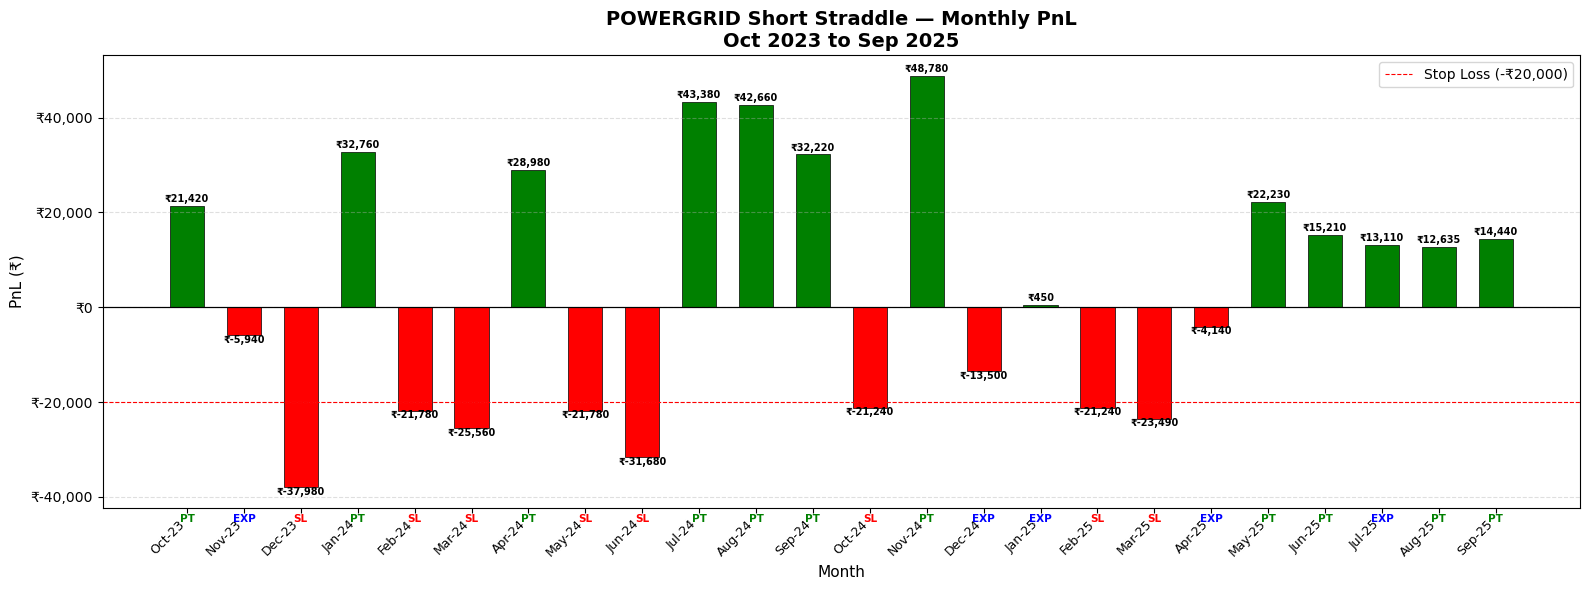

In [11]:
fig, ax = plt.subplots(figsize=(16, 6))

colors = ['green' if p >= 0 else 'red' for p in results_df['PnL']]
bars   = ax.bar(results_df['Month'], results_df['PnL'],
                color=colors, edgecolor='black', linewidth=0.5, width=0.6)

# ── Value labels on each bar ──────────────────────────────────────────
for bar, val in zip(bars, results_df['PnL']):
    label_y = bar.get_height() + 400 if val >= 0 else bar.get_height() - 2000
    ax.text(bar.get_x() + bar.get_width()/2, label_y,
            f'₹{val:,.0f}', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='black')

# ── Exit reason tag below each bar ───────────────────────────────────
y_min = min(results_df['PnL'].min() * 1.15, -5000)
for idx, reason in enumerate(results_df['Exit_Reason']):
    tag   = 'PT' if 'Profit' in reason else ('SL' if 'Stop' in reason else 'EXP')
    color = 'green' if tag == 'PT' else ('red' if tag == 'SL' else 'blue')
    ax.text(idx, y_min, tag, ha='center', va='top',
            fontsize=7.5, fontweight='bold', color=color)

ax.axhline(0,          color='black', linewidth=0.8)
ax.axhline(-20000,     color='red',   linewidth=0.8,
           linestyle='--', label='Stop Loss (-₹20,000)')
ax.axhline(0,          color='black', linewidth=0.8)

ax.set_title('POWERGRID Short Straddle — Monthly PnL\nOct 2023 to Sep 2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('PnL (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
# ── Date range ────────────────────────────────────────────────────────
ss_start   = results_df['Entry_Date'].iloc[0]
ss_end     = results_df['Expiry_Date'].iloc[-1]
ss_years   = (ss_end - ss_start).days / 365.25

# ── Return metrics ────────────────────────────────────────────────────
FIXED_CAPITAL    = 130000
total_pnl        = results_df['PnL'].sum()
final_capital    = FIXED_CAPITAL + total_pnl
ss_abs_return    = (total_pnl / FIXED_CAPITAL) * 100
ss_cagr          = ((final_capital / FIXED_CAPITAL) ** (1 / ss_years) - 1) * 100

# ── Monthly return series ─────────────────────────────────────────────
m_ret            = results_df['Return_%'] / 100
ss_ann_vol       = m_ret.std() * np.sqrt(12) * 100

# ── Sharpe ────────────────────────────────────────────────────────────
rf_monthly       = (1 + 0.065) ** (1/12) - 1
excess           = m_ret - rf_monthly
ss_sharpe        = (excess.mean() / excess.std()) * np.sqrt(12)

# ── Sortino ───────────────────────────────────────────────────────────
downside         = m_ret[m_ret < 0]
ss_sortino       = ((m_ret.mean() - rf_monthly) * 12) / (downside.std() * np.sqrt(12))

# ── Max Drawdown ──────────────────────────────────────────────────────
cumul            = (1 + m_ret).cumprod()
roll_max         = cumul.cummax()
dd_series        = (cumul - roll_max) / roll_max * 100
ss_max_dd        = dd_series.min()
ss_calmar        = (ss_cagr / 100) / abs(ss_max_dd / 100)

# ── Trade stats ───────────────────────────────────────────────────────
total_trades     = len(results_df)
wins             = results_df[results_df['PnL'] > 0]
losses           = results_df[results_df['PnL'] <= 0]
ss_win_rate      = len(wins) / total_trades * 100
avg_win          = wins['PnL'].mean()
avg_loss         = losses['PnL'].mean()
ss_payoff        = abs(avg_win / avg_loss)
ss_pf            = wins['PnL'].sum() / abs(losses['PnL'].sum())
ss_expectancy    = (ss_win_rate/100 * avg_win) + ((1 - ss_win_rate/100) * avg_loss)

best_t           = results_df.loc[results_df['PnL'].idxmax()]
worst_t          = results_df.loc[results_df['PnL'].idxmin()]
sl_count         = results_df['Exit_Reason'].str.contains('Stop').sum()
pt_count         = results_df['Exit_Reason'].str.contains('Profit').sum()
exp_count        = (results_df['Exit_Reason'] == 'Expiry').sum()

# ── Print scorecard ───────────────────────────────────────────────────
print("=" * 54)
print("   POWERGRID SHORT STRADDLE — PERFORMANCE SCORECARD")
print("=" * 54)
print(f"  Period               : {ss_start.date()}  →  {ss_end.date()}")
print(f"  Total Months Traded  : {total_trades}")
print(f"  Fixed Capital        : ₹{FIXED_CAPITAL:,}")
print("-" * 54)
print(f"  Total PnL            : ₹{total_pnl:,.2f}")
print(f"  Absolute Return      : {ss_abs_return:.2f}%")
print(f"  CAGR                 : {ss_cagr:.2f}%")
print(f"  Annual Volatility    : {ss_ann_vol:.2f}%")
print("-" * 54)
print(f"  Sharpe Ratio         : {ss_sharpe:.2f}")
print(f"  Sortino Ratio        : {ss_sortino:.2f}")
print(f"  Calmar Ratio         : {ss_calmar:.2f}")
print(f"  Max Drawdown         : {ss_max_dd:.2f}%")
print("-" * 54)
print(f"  Win Rate             : {ss_win_rate:.1f}%  ({len(wins)}/{total_trades})")
print(f"  Avg Winning Trade    : ₹{avg_win:,.2f}")
print(f"  Avg Losing Trade     : ₹{avg_loss:,.2f}")
print(f"  Payoff Ratio         : {ss_payoff:.2f}x")
print(f"  Profit Factor        : {ss_pf:.2f}")
print(f"  Expectancy/Trade     : ₹{ss_expectancy:,.2f}")
print("-" * 54)
print(f"  Best Trade           : {best_t['Month']}  ₹{best_t['PnL']:,.2f}")
print(f"  Worst Trade          : {worst_t['Month']}  ₹{worst_t['PnL']:,.2f}")
print("-" * 54)
print(f"  Profit Target Exits  : {pt_count}")
print(f"  Stop Loss Exits      : {sl_count}")
print(f"  Expiry Exits         : {exp_count}")
print("=" * 54)

   POWERGRID SHORT STRADDLE — PERFORMANCE SCORECARD
  Period               : 2023-10-03  →  2025-09-30
  Total Months Traded  : 24
  Fixed Capital        : ₹130,000
------------------------------------------------------
  Total PnL            : ₹99,945.00
  Absolute Return      : 76.88%
  CAGR                 : 33.13%
  Annual Volatility    : 70.45%
------------------------------------------------------
  Sharpe Ratio         : 0.46
  Sortino Ratio        : 1.21
  Calmar Ratio         : 0.59
  Max Drawdown         : -56.45%
------------------------------------------------------
  Win Rate             : 54.2%  (13/24)
  Avg Winning Trade    : ₹25,251.92
  Avg Losing Trade     : ₹-20,757.27
  Payoff Ratio         : 1.22x
  Profit Factor        : 1.44
  Expectancy/Trade     : ₹4,164.37
------------------------------------------------------
  Best Trade           : Nov-24  ₹48,780.00
  Worst Trade          : Dec-23  ₹-37,980.00
------------------------------------------------------
  Profi

   POWERGRID: BUY & HOLD  vs  SHORT STRADDLE
   Oct 2023 → Sep 2025
  METRIC                         BUY & HOLD   SHORT STRADDLE
  Absolute Return                    40.44%           76.88%
  CAGR                               18.58%           33.13%
  Annual Volatility                  27.12%           70.45%
----------------------------------------------------------------
  Sharpe Ratio                         0.45            0.46
  Sortino Ratio                        0.61            1.21
  Calmar Ratio                         0.59            0.59
  Max Drawdown                      -31.36%          -56.45%
----------------------------------------------------------------
  Monthly Win Rate                    54.2%            54.2%
  Payoff Ratio                        1.17x           1.22x
  Profit Factor                         N/A            1.44
  Expectancy/Trade                      N/A ₹     4,164.37

  VERDICT
----------------------------------------------------------------
 

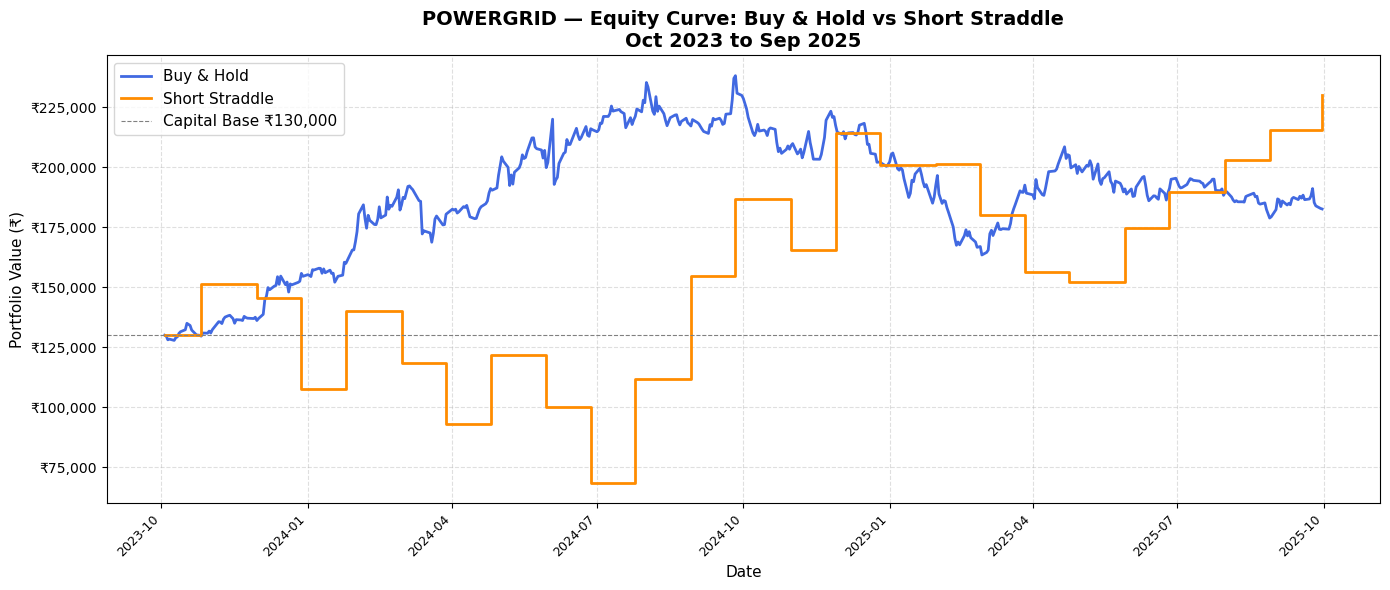

In [15]:
# ── Buy & Hold metrics (reusing Cell 4 variables) ─────────────────────
print("=" * 64)
print("   POWERGRID: BUY & HOLD  vs  SHORT STRADDLE")
print("   Oct 2023 → Sep 2025")
print("=" * 64)
print(f"  {'METRIC':<26} {'BUY & HOLD':>14} {'SHORT STRADDLE':>16}")
print("=" * 64)
print(f"  {'Absolute Return':<26} {absolute_return:>13.2f}% {ss_abs_return:>15.2f}%")
print(f"  {'CAGR':<26} {cagr:>13.2f}% {ss_cagr:>15.2f}%")
print(f"  {'Annual Volatility':<26} {annual_volatility:>13.2f}% {ss_ann_vol:>15.2f}%")
print("-" * 64)
print(f"  {'Sharpe Ratio':<26} {sharpe_ratio:>14.2f} {ss_sharpe:>15.2f}")
print(f"  {'Sortino Ratio':<26} {sortino_ratio:>14.2f} {ss_sortino:>15.2f}")
print(f"  {'Calmar Ratio':<26} {calmar_ratio:>14.2f} {ss_calmar:>15.2f}")
print(f"  {'Max Drawdown':<26} {max_drawdown:>13.2f}% {ss_max_dd:>15.2f}%")
print("-" * 64)
print(f"  {'Monthly Win Rate':<26} {win_rate:>13.1f}% {ss_win_rate:>15.1f}%")
print(f"  {'Payoff Ratio':<26} {payoff_ratio:>13.2f}x {ss_payoff:>14.2f}x")
print(f"  {'Profit Factor':<26} {'N/A':>14} {ss_pf:>15.2f}")
print(f"  {'Expectancy/Trade':<26} {'N/A':>14} ₹{ss_expectancy:>13,.2f}")
print("=" * 64)
print()
print("  VERDICT")
print("-" * 64)
metrics = {
    'Higher CAGR'      : (ss_cagr,       cagr,          True),
    'Better Sharpe'    : (ss_sharpe,     sharpe_ratio,  True),
    'Lower Volatility' : (ss_ann_vol,    annual_volatility, False),
    'Lower Drawdown'   : (abs(ss_max_dd),abs(max_drawdown), False),
}
for label, (ss_val, bh_val, higher_is_better) in metrics.items():
    if higher_is_better:
        winner = 'Short Straddle ✅' if ss_val > bh_val else 'Buy & Hold ✅'
    else:
        winner = 'Short Straddle ✅' if ss_val < bh_val else 'Buy & Hold ✅'
    print(f"  {label:<26} {winner}")
print("=" * 64)

# ── Equity Curve ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Buy & Hold — normalised to ₹1,30,000 base
stock_plot = stock_df.sort_values('DATE').copy()
stock_plot['BH_Capital'] = FIXED_CAPITAL * (
    stock_plot['CLOSE'] / stock_plot['CLOSE'].iloc[0])
ax.plot(stock_plot['DATE'], stock_plot['BH_Capital'],
        color='royalblue', linewidth=2, label='Buy & Hold')

# Short Straddle — step curve
ss_dates   = [ss_start] + results_df['Expiry_Date'].tolist()
ss_capital = [FIXED_CAPITAL] + (FIXED_CAPITAL + results_df['PnL'].cumsum()).tolist()
ax.step(ss_dates, ss_capital, where='post',
        color='darkorange', linewidth=2, label='Short Straddle')

ax.axhline(FIXED_CAPITAL, color='grey', linewidth=0.8,
           linestyle='--', label=f'Capital Base ₹{FIXED_CAPITAL:,}')

ax.set_title('POWERGRID — Equity Curve: Buy & Hold vs Short Straddle\n'
             'Oct 2023 to Sep 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Portfolio Value (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()